# 2×2 CIG Curves (Excluding CCL)

This notebook is intentionally orchestration-only: experiment choices stay here, while reusable loading, split handling, phase detection, curve transformation, and plotting live under `src/utils`.

Changing `PLOT_START_MODE` and running from **Load validated curves** downward updates the CIG curves, phase ribbon, split markers, injection/count panels, x-axis labels, and output filenames together.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

SANS_SERIF_FONTS = [
    'Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans',
]
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})

cwd = Path.cwd().resolve()
for candidate in (cwd, cwd.parent):
    if (candidate / 'src').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Cannot find project root containing 'src'.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.cig_plotting import CIGPlotConfig, cig_figure_stem, load_cig_datasets, plot_cig_grid
from src.utils.combined_location_injection_plot import plot_location_injection_count_combined
from src.utils.dataset_location_map import (
    LocationMapConfig, plot_dataset_location_map, save_location_map, show_location_map,
)
from src.utils.injection_count_plot import InjectionCountPlotConfig, plot_injection_count_grid
from src.utils.injection_phases import build_panel_phase_annotations
from src.utils.plot_style import save_pub_figure
from src.utils.runtime_utils import resolve_project_root

PROJECT_ROOT = resolve_project_root()
NOTEBOOK_NAME = 'cumulative_likelihood_over_time'
METRIC_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'metrics' / NOTEBOOK_NAME
FIG_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / NOTEBOOK_NAME
FIG_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'METRIC_EXPORT_DIR = {METRIC_EXPORT_DIR}')
print(f'FIG_EXPORT_DIR = {FIG_EXPORT_DIR}')

PROJECT_ROOT = /root/autodl-tmp/em_eqf
METRIC_EXPORT_DIR = /root/autodl-tmp/em_eqf/notebooks/metrics/cumulative_likelihood_over_time
FIG_EXPORT_DIR = /root/autodl-tmp/em_eqf/notebooks/figs/cumulative_likelihood_over_time


## Configuration

`PLOT_START_MODE` controls only the displayed left edge. `SPLIT` controls which exported CSV is loaded. Split-relative modes now fail explicitly when their metadata boundary is unavailable instead of silently behaving like `full`.

In [2]:
DATASET_CONFIGS = [
    {'config_name': 'CB_HAB1a', 'dataset': 'CB_HAB1a', 'title': 'CB1a'},
    {'config_name': 'CB_HAB4', 'dataset': 'CB_HAB4', 'title': 'CB4'},
    {'config_name': 'PNR_1z', 'dataset': 'PNR_1z', 'title': 'PNR1z'},
    {'config_name': 'St1_2018', 'dataset': 'St1-2018', 'title': 'ST1-2018'},
]

SPLIT = 'test'
SEQ_INDEX = 0
PLOT_START_MODE = 'full'  # Options: 'val', 'test', 'full'
SPLIT_BOUNDARY_SOURCE = 'checkpoint'  # Options: 'catalog', 'checkpoint', 'manual'
CHECKPOINT_MODEL_SPEC_PATH = (
    PROJECT_ROOT / 'notebooks/config/model_specs/cumulative_likelihood_over_time/'
    'model_specs.cumulative_likelihood_over_time.v1.json'
)
CHECKPOINT_MODEL_LABEL = 'ETAS+mamba'
CHECKPOINT_PATH_OVERRIDES = {}
MANUAL_SPLIT_BOUNDARIES = {}

PLOT_VALUE_COLUMN = 'cum_log_likelihood_delta'
PLOT_VALUE_FALLBACK_COLUMN = 'plot_value'
RESET_Y_AT_PLOT_START = True
RESET_CIG_AT_SPLIT_BOUNDARIES = False
CIG_RESET_BOUNDARY_SPLITS = ('val', 'test')

MODEL_LABEL_ORDER = [
    'ETAS+p', 'ETAS+conv', 'ETAS+mamba', 'RECAST',
    'RECAST+p', 'RECAST+conv', 'RECAST+mamba', 'ORACLE',
]
MODEL_DISPLAY_LABELS = {
    'ETAS+p': 'ETAS-p', 'ETAS+conv': 'ETAS-conv', 'ETAS+mamba': 'ETAS-Mamba',
    'RECAST': 'RECAST', 'RECAST+p': 'RECAST-p', 'RECAST+conv': 'RECAST-conv',
    'RECAST+mamba': 'RECAST-Mamba', 'ORACLE': 'ORACLE',
}
MODEL_STYLE_MAP = {
    'RECAST': {'color': '#555555', 'linestyle': '--', 'linewidth': 1.85, 'alpha': 0.95},
    'ETAS+p': {'color': '#1b9e77', 'linestyle': '-', 'linewidth': 1.75, 'alpha': 0.95},
    'RECAST+p': {'color': '#1b9e77', 'linestyle': '--', 'linewidth': 1.85, 'alpha': 0.95},
    'ETAS+conv': {'color': '#d95f02', 'linestyle': '-', 'linewidth': 1.75, 'alpha': 0.95},
    'RECAST+conv': {'color': '#d95f02', 'linestyle': '--', 'linewidth': 1.85, 'alpha': 0.95},
    'ETAS+mamba': {'color': '#7570b3', 'linestyle': '-', 'linewidth': 1.75, 'alpha': 0.95},
    'RECAST+mamba': {'color': '#7570b3', 'linestyle': '--', 'linewidth': 1.85, 'alpha': 0.95},
    'ORACLE': {'color': '#222222', 'linestyle': '-.', 'linewidth': 2.05, 'alpha': 0.95},
}

CIG_PLOT = CIGPlotConfig(
    start_mode=PLOT_START_MODE,
    reset_y_at_plot_start=RESET_Y_AT_PLOT_START,
    reset_at_split_boundaries=RESET_CIG_AT_SPLIT_BOUNDARIES,
    reset_boundary_splits=CIG_RESET_BOUNDARY_SPLITS,
    model_label_order=MODEL_LABEL_ORDER,
    exclude_labels={'ETAS'},
    model_display_labels=MODEL_DISPLAY_LABELS,
    model_style_map=MODEL_STYLE_MAP,
    direct_labels=True,
    show_legend=False,
    figsize=(13.8, 5.0),
)
INJECTION_PLOT = InjectionCountPlotConfig(start_mode=PLOT_START_MODE)
LOCATION_MAP = LocationMapConfig(
    data_root=PROJECT_ROOT / 'data',
    use_pygmt=True,
    world_shapefile=PROJECT_ROOT / 'data/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp',
    location_fallbacks={
        'St1-2018': {'lat': 60.1926, 'lon': 24.8363, 'source': 'fallback approximate project site'},
    },
    projected_crs={'St1-2018': 'EPSG:3879'},
    label_offsets={
        'CB_HAB1a': (4.0, -7.0), 'CB_HAB4': (4.0, 4.0),
        'PNR_1z': (4.0, 5.0), 'St1-2018': (4.0, 5.0),
    },
    pygmt_colors={
        'CB_HAB1a': 'blue', 'CB_HAB4': 'orange',
        'PNR_1z': 'green', 'St1-2018': 'red',
    },
)

DRAW_CIG = True
DRAW_INJECTION_COUNTS = True
DRAW_LOCATION_MAP = True
DRAW_COMBINED_FIGURE = True
EXPORT_CROPPED_DATA = False
SAVE_PDF = True
SAVE_PNG = True
DPI = 300

if SPLIT != 'test':
    print('Warning: existing default exports use SPLIT="test"; verify matching CSVs exist.')

## Load validated curves

The loader resolves the selected checkpoint metadata, validates every CSV, and materializes `plot_start_days` once for all downstream figures.

In [3]:
loaded_datasets, summary_df, missing_by_dataset = load_cig_datasets(
    DATASET_CONFIGS,
    project_root=PROJECT_ROOT,
    metric_export_dir=METRIC_EXPORT_DIR,
    split=SPLIT,
    sequence_index=SEQ_INDEX,
    plot_start_mode=PLOT_START_MODE,
    boundary_source=SPLIT_BOUNDARY_SOURCE,
    checkpoint_model_spec_path=CHECKPOINT_MODEL_SPEC_PATH,
    checkpoint_model_label=CHECKPOINT_MODEL_LABEL,
    checkpoint_path_overrides=CHECKPOINT_PATH_OVERRIDES,
    manual_split_boundaries=MANUAL_SPLIT_BOUNDARIES,
    preferred_value_column=PLOT_VALUE_COLUMN,
    fallback_value_column=PLOT_VALUE_FALLBACK_COLUMN,
    expected_labels=MODEL_LABEL_ORDER,
    excluded_labels=CIG_PLOT.exclude_labels,
    display_labels=MODEL_DISPLAY_LABELS,
)
if missing_by_dataset:
    print('Warning: configured model labels are missing:')
    for dataset, labels in missing_by_dataset.items():
        print(f'  - {dataset}: {labels}')
display(summary_df)

/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


,dataset,title,registry,rows,labels,min_days,max_days,val_start_days,test_start_days,plot_start_days,split_boundary_source,checkpoint_path,plot_value_column,curve_path
0,CB_HAB1a,CB1a,CB_HAB1a-Standard,60345,"ETAS, ETAS-p, ETAS-conv, ETAS-Mamba, RECAST, R...",0.000001,46.748615,31.188727,32.943264,0.000001,checkpoint,/root/autodl-tmp/em_eqf/experiments/etas_multi...,cum_log_likelihood_delta,notebooks/metrics/cumulative_likelihood_over_t...
1,CB_HAB4,CB4,CB_HAB4-Standard,42174,"ETAS, ETAS-p, ETAS-conv, ETAS-Mamba, RECAST, R...",0.000001,23.797220,18.257766,19.725475,0.000001,checkpoint,/root/autodl-tmp/em_eqf/experiments/etas_multi...,cum_log_likelihood_delta,notebooks/metrics/cumulative_likelihood_over_t...
2,PNR_1z,PNR1z,PNR_1z-Standard,55296,"ETAS, ETAS-p, ETAS-conv, ETAS-Mamba, RECAST, R...",0.000001,64.208336,56.087431,59.152674,0.000001,checkpoint,/root/autodl-tmp/em_eqf/experiments/etas_multi...,cum_log_likelihood_delta,notebooks/metrics/cumulative_likelihood_over_t...
3,St1-2018,ST1-2018,St1-2018-Standard,272295,"ETAS, ETAS-p, ETAS-conv, ETAS-Mamba, RECAST, R...",0.000001,78.772598,36.140528,44.214057,0.000001,checkpoint,/root/autodl-tmp/em_eqf/experiments/etas_multi...,cum_log_likelihood_delta,notebooks/metrics/cumulative_likelihood_over_t...


## CIG curves and operation-phase ribbon

/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


CB1a phase boundaries since curve start: 3.029 d, 16.118 d, 23.536 d, 33.389 d, 45.623 d
CB4 phase boundaries since curve start: 2.878 d, 4.458 d, 6.434 d, 20.027 d
PNR1z phase boundaries since curve start: 18.559 d, 54.034 d, 58.064 d, 62.115 d, 63.218 d
ST1-2018 phase boundaries since curve start: 48.436 d
Saved phase boundaries: /root/autodl-tmp/em_eqf/notebooks/metrics/cumulative_likelihood_over_time/cig_phases.csv
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/cumulative_likelihood_over_time/cig_from_full.pdf
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/cumulative_likelihood_over_time/cig_from_full.png


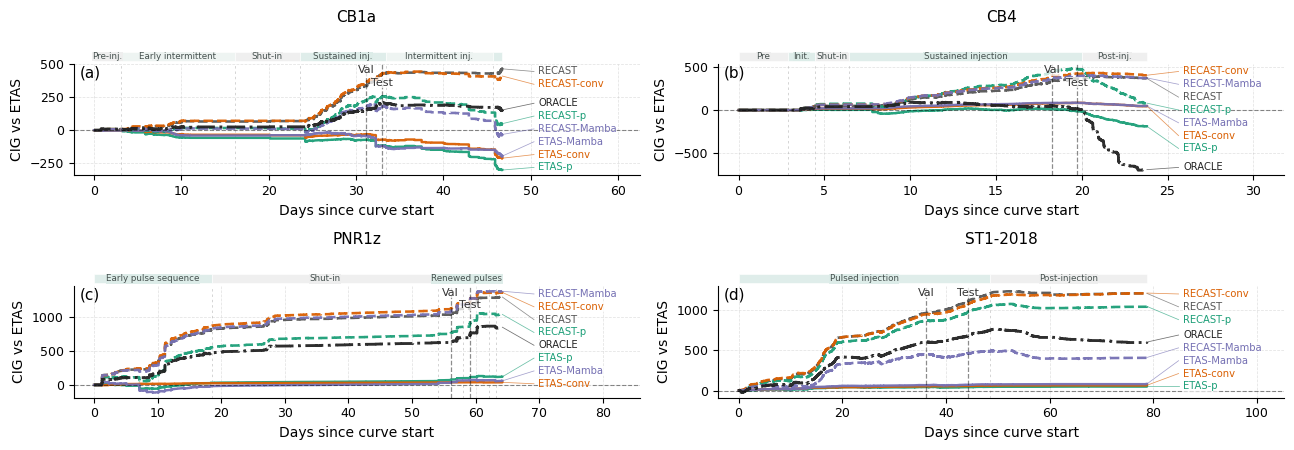

In [4]:
plotted_data = None
if DRAW_CIG:
    phase_annotations, phase_boundary_summary_df = build_panel_phase_annotations(
        loaded_datasets, data_root=PROJECT_ROOT / 'data'
    )
    phase_summary_path = (
        METRIC_EXPORT_DIR / 'cig_phases.csv'
    )
    phase_boundary_summary_df.to_csv(phase_summary_path, index=False)

    cig_fig, cig_axes, plotted_data = plot_cig_grid(
        loaded_datasets, config=CIG_PLOT, phase_annotations=phase_annotations
    )
    cig_stem = cig_figure_stem(CIG_PLOT)
    saved_cig_paths = {}
    if SAVE_PDF:
        saved_cig_paths['pdf'] = save_pub_figure(cig_fig, FIG_EXPORT_DIR / cig_stem, file_format='pdf')
    if SAVE_PNG:
        saved_cig_paths['png'] = save_pub_figure(
            cig_fig, FIG_EXPORT_DIR / cig_stem, dpi=DPI, file_format='png'
        )
    print(f'Saved phase boundaries: {phase_summary_path}')
    for path in saved_cig_paths.values():
        print(f'Saved: {path}')
    plt.show()
else:
    print('DRAW_CIG is False; skipped CIG figure.')

## Injection rate and earthquake counts

Loaded CB_HAB1a injection/count series from CB_HAB1a-Standard (raw_time_series).
Loaded CB_HAB4 injection/count series from CB_HAB4-Standard (raw_time_series).
Loaded PNR_1z injection/count series from PNR_1z-Standard (time_series).
Loaded St1-2018 injection/count series from St1-2018-Standard (raw_time_series).


/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Saved: /root/autodl-tmp/em_eqf/notebooks/figs/cumulative_likelihood_over_time/injection_count_daily_from_full.pdf
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/cumulative_likelihood_over_time/injection_count_daily_from_full.png


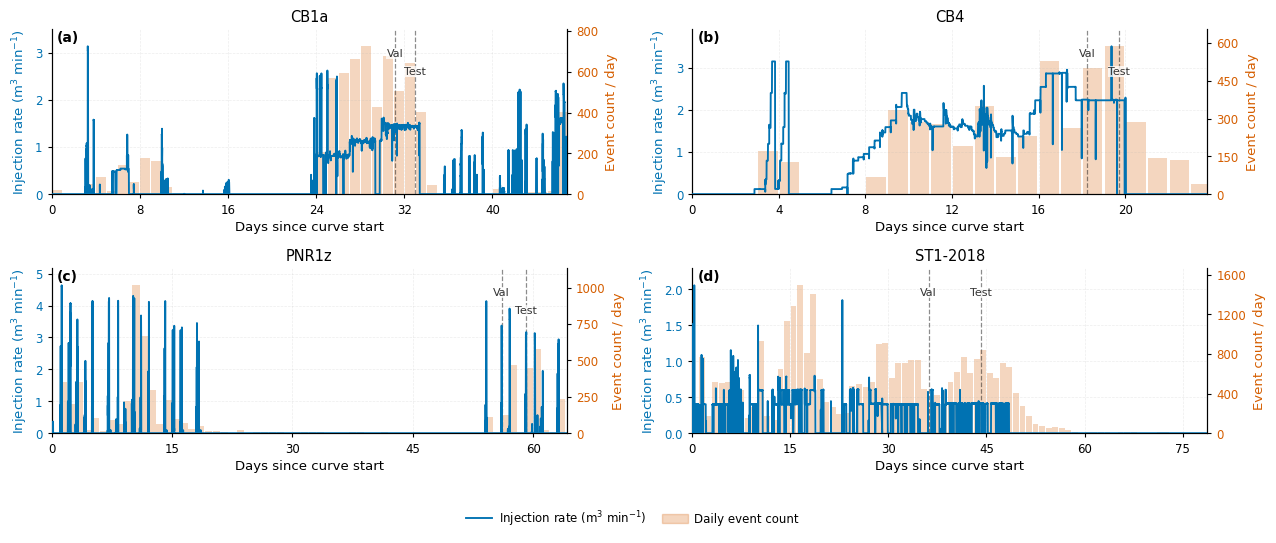

In [5]:
if DRAW_INJECTION_COUNTS:
    injection_fig, injection_axes, injection_overlays = plot_injection_count_grid(
        loaded_datasets, data_root=PROJECT_ROOT / 'data', config=INJECTION_PLOT
    )
    injection_stem = f'injection_count_daily_from_{PLOT_START_MODE}'
    saved_injection_paths = {}
    if SAVE_PDF:
        saved_injection_paths['pdf'] = save_pub_figure(
            injection_fig, FIG_EXPORT_DIR / injection_stem, file_format='pdf'
        )
    if SAVE_PNG:
        saved_injection_paths['png'] = save_pub_figure(
            injection_fig, FIG_EXPORT_DIR / injection_stem, dpi=DPI, file_format='png'
        )
    for path in saved_injection_paths.values():
        print(f'Saved: {path}')
    plt.show()
else:
    print('DRAW_INJECTION_COUNTS is False; skipped injection/count figure.')

## Dataset locations

Saved: /root/autodl-tmp/em_eqf/notebooks/figs/cumulative_likelihood_over_time/locations_pygmt.pdf
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/cumulative_likelihood_over_time/locations_pygmt.png


,dataset,title,center_lat,center_lon,n_location_points,source
0,CB_HAB1a,CB1a,-27.815082,140.754044,23285,data/CB_HAB1a/processed/CB_HAB1a_eq_processed.csv
1,CB_HAB4,CB4,-27.810613,140.758835,20735,data/CB_HAB4/processed/CB_HAB4_eq_processed.csv
2,PNR_1z,PNR1z,53.787200,-2.967280,38246,data/PNR_1z/raw/PNR_1z_catalog.csv
3,St1-2018,ST1-2018,60.192904,24.837320,1986,data/St1-2018/processed/St1-2018_eq_processed....


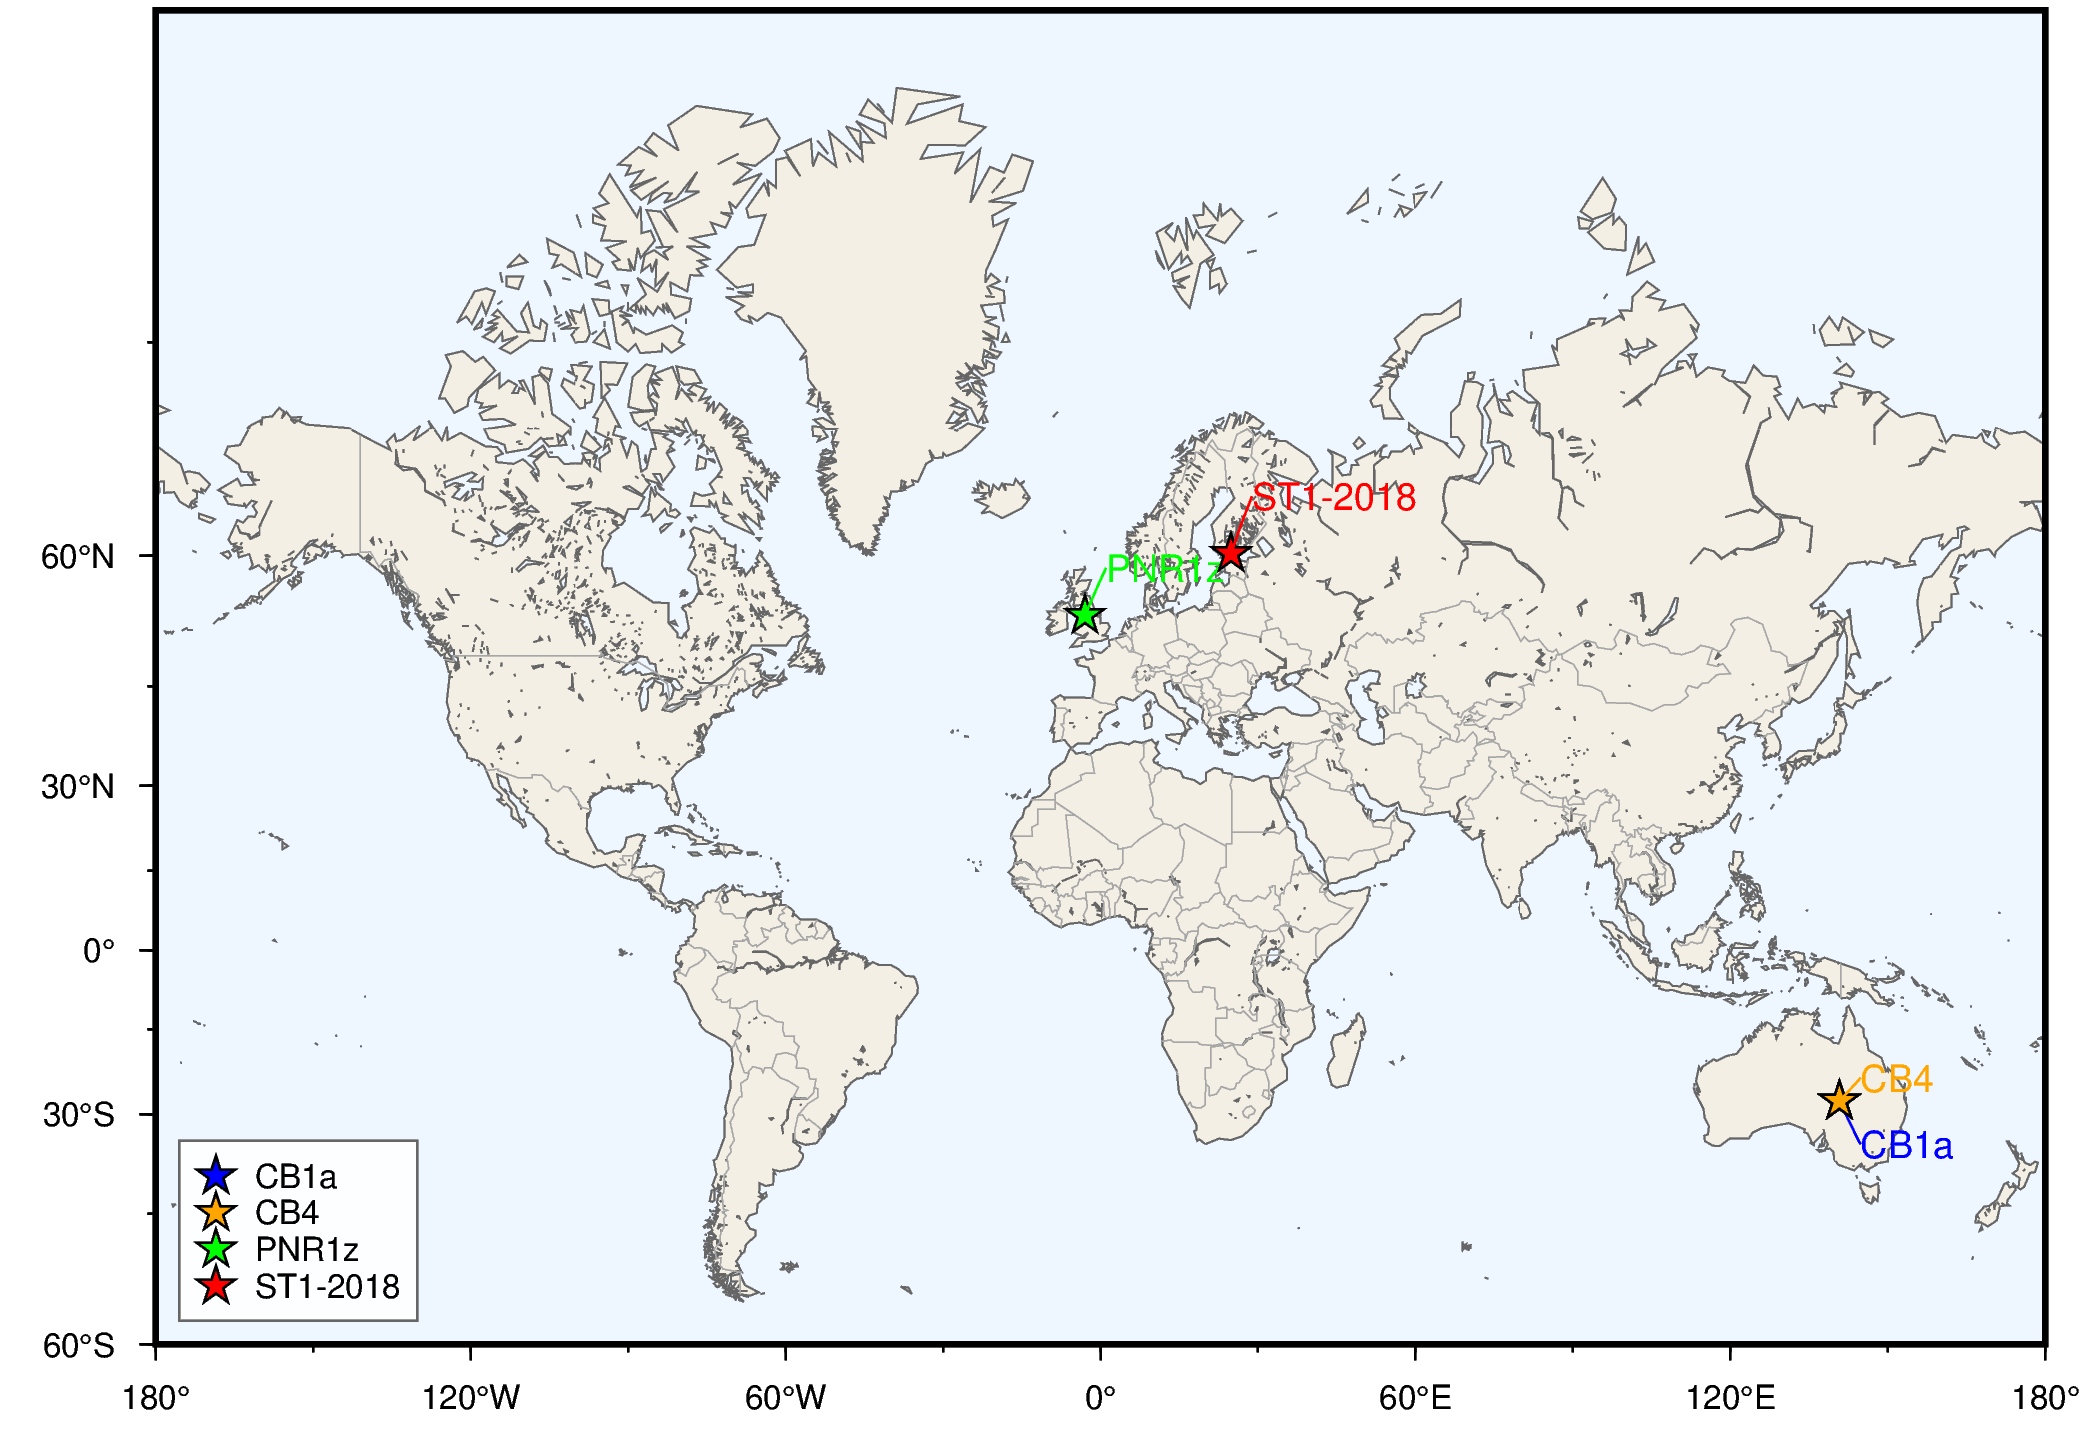

In [6]:
if DRAW_LOCATION_MAP:
    location_fig, location_summary_df = plot_dataset_location_map(loaded_datasets, LOCATION_MAP)
    map_backend = 'pygmt' if LOCATION_MAP.use_pygmt else 'matplotlib'
    map_stem = f'locations_{map_backend}'
    saved_map_paths = save_location_map(
        location_fig,
        output_dir=FIG_EXPORT_DIR,
        stem=map_stem,
        config=LOCATION_MAP,
        save_pdf=SAVE_PDF,
        save_png=SAVE_PNG,
        dpi=DPI,
    )
    for path in saved_map_paths.values():
        print(f'Saved: {path}')
    display(location_summary_df)
    show_location_map(location_fig, LOCATION_MAP)
else:
    print('DRAW_LOCATION_MAP is False; skipped dataset location map.')

## Combined location map and injection/count panels

This additional export places a compact, centered location map above the full-width 2×2 time-series grid. The existing standalone figures remain unchanged.

Loaded CB_HAB1a injection/count series from CB_HAB1a-Standard (raw_time_series).
Loaded CB_HAB4 injection/count series from CB_HAB4-Standard (raw_time_series).
Loaded PNR_1z injection/count series from PNR_1z-Standard (time_series).


/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Loaded St1-2018 injection/count series from St1-2018-Standard (raw_time_series).
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/cumulative_likelihood_over_time/combined_locations_injection_count_from_full.pdf
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/cumulative_likelihood_over_time/combined_locations_injection_count_from_full.png


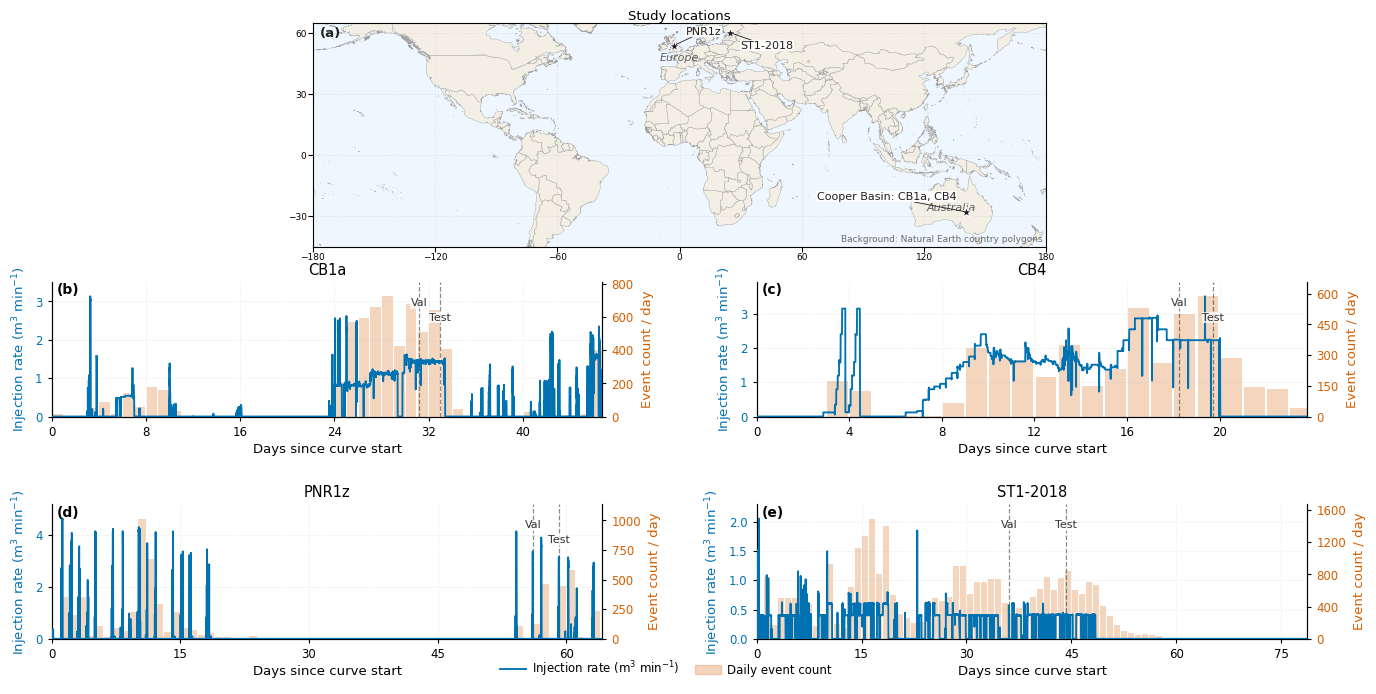

In [7]:
if DRAW_COMBINED_FIGURE and DRAW_LOCATION_MAP and DRAW_INJECTION_COUNTS:
    combined_fig, combined_axes, combined_overlays = plot_location_injection_count_combined(
        loaded_datasets,
        data_root=PROJECT_ROOT / 'data',
        location_config=LOCATION_MAP,
        injection_config=INJECTION_PLOT,
        figsize=(13.8, 7.0),
        map_width_fraction=0.68,
    )
    combined_stem = f'combined_locations_injection_count_from_{PLOT_START_MODE}'
    saved_combined_paths = {}
    if SAVE_PDF:
        saved_combined_paths['pdf'] = save_pub_figure(
            combined_fig, FIG_EXPORT_DIR / combined_stem, file_format='pdf'
        )
    if SAVE_PNG:
        saved_combined_paths['png'] = save_pub_figure(
            combined_fig, FIG_EXPORT_DIR / combined_stem, dpi=DPI, file_format='png'
        )
    for path in saved_combined_paths.values():
        print(f'Saved: {path}')
    plt.show()
else:
    print('Combined figure skipped; enable DRAW_COMBINED_FIGURE, DRAW_LOCATION_MAP, and DRAW_INJECTION_COUNTS.')

## Optional reproducibility export

This exports the exact cropped and reset values drawn in the CIG panels.

In [8]:
if EXPORT_CROPPED_DATA:
    if plotted_data is None:
        raise RuntimeError('DRAW_CIG must be True before exporting plotted data.')
    cropped_path = METRIC_EXPORT_DIR / f'{cig_stem}_curves.csv'
    plotted_data.to_csv(cropped_path, index=False)
    print(f'Saved: {cropped_path}')
else:
    print('EXPORT_CROPPED_DATA is False; no long-format export written.')

EXPORT_CROPPED_DATA is False; no long-format export written.
